# Session 1: Ensemble Strategy — Market Regime Identification and Combination Algorithm

This notebook implements the **Ensemble Strategy** discussed on **Slide 21** of the Session 1 Presentation. 
The core concept is to use a **Market Regime Identifier** (the **Average Directional Index - ADX**) to dynamically combine two distinct strategies: 
1. **Mean Reversion Strategy**: Highly effective in ranging/non-trending markets but vulnerable to severe losses during major trend breakouts.
2. **Momentum Strategy**: Highly effective in strongly trending markets but prone to frequent whipsaw losses in ranging markets.

By ensembling these two strategies based on the current market regime, we aim to:
- **Dynamically allocate capital** (adjust weights) between mean reversion and momentum.
- **Filter out trades** that are inappropriate for the current regime (block momentum in ranges, block mean reversion in trends).


## Core Concepts from Slide 21

### 1. Welles Wilder's ADX (Average Directional Index)
The ADX is a technical indicator that measures the **strength** of a trend, regardless of its direction. It functions as an ideal **Regime Identifier**.

### 2. Market Regime Thresholds
- **ADX < 20–25 (Ranging / Non-Trending)**: Trend momentum is weak. Prices tend to trade within a range, making it ideal for the **Mean Reversion** strategy.
- **ADX > 25 (Strongly Trending)**: Price is breaking out and moving strongly in one direction. Ideal for the **Momentum** strategy.
- **ADX > 40–50 (Extreme Trend / Overheated)**: The trend is extremely overextended. This indicates an overheated state, suggesting a high probability of trend exhaustion and reversal. Traders should prepare for trend tops and reversal opportunities.

### 3. Ensemble Core Functions
- **Dynamic Allocation (Continuous Weights)**: Adjust the relative weight of each strategy in the portfolio in real-time based on the ADX values.
- **Hard Filtering (Binary Switching)**: Stop mean reversion during strong trends (ADX > 25) to prevent fighting a breakout. Stop momentum during ranges (ADX < 25) to prevent whipsaws.


## 1. Imports and Configurations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

# Set style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False


## 2. Parameter Definitions


In [2]:
WINDOW = {
    'start': '2022-10-01',
    'end': '2026-09-01'
}
TRAIN_RANGE = slice('2022-10-01', '2025-09-30')
TEST_RANGE = slice('2025-10-01', '2026-09-01')

# Transaction Costs
TRANSACTION_COST_RATE = 0.0010  # 10 bps per trade

# Assets
MEAN_REVERSION_PAIR = {
    'stock1': 'EBAY',
    'stock2': 'AVGO'
}
MOMENTUM_STOCK = 'HPE'


## 3. Data Loading & Index Alignment


In [3]:
print('Downloading stock historical data...')
ebay_data = yf.Ticker(MEAN_REVERSION_PAIR['stock1']).history(start=WINDOW['start'], end=WINDOW['end'], auto_adjust=True)
avgo_data = yf.Ticker(MEAN_REVERSION_PAIR['stock2']).history(start=WINDOW['start'], end=WINDOW['end'], auto_adjust=True)
hpe_data = yf.Ticker(MOMENTUM_STOCK).history(start=WINDOW['start'], end=WINDOW['end'], auto_adjust=True)

# Align indices to ensure identical trading days
common_index = ebay_data.index.intersection(avgo_data.index).intersection(hpe_data.index)
ebay = ebay_data.loc[common_index].copy()
avgo = avgo_data.loc[common_index].copy()
hpe = hpe_data.loc[common_index].copy()

print(f'Aligned dataset has {len(common_index)} business days.')


Aligned dataset has 981 business days.


## 4. Technical Indicator Calculations

We implement Welles Wilder's original ADX smoothing. To comply with strict code style preferences, we never abbreviate variable names (e.g. `true_range` instead of `tr`).


In [4]:
def calculate_average_directional_index(dataframe, lookback_period=14):
    dataframe = dataframe.copy()
    high_prices = dataframe['High']
    low_prices = dataframe['Low']
    close_prices = dataframe['Close']
    
    # 1. True Range
    previous_close_prices = close_prices.shift(1)
    true_range = pd.concat([
        high_prices - low_prices,
        (high_prices - previous_close_prices).abs(),
        (low_prices - previous_close_prices).abs()
    ], axis=1).max(axis=1)
    
    # 2. Directional Movement
    upward_movement = high_prices.diff()
    downward_movement = -low_prices.diff()
    
    plus_directional_movement = pd.Series(
        np.where((upward_movement > downward_movement) & (upward_movement > 0), upward_movement, 0.0),
        index=dataframe.index
    )
    minus_directional_movement = pd.Series(
        np.where((downward_movement > upward_movement) & (downward_movement > 0), downward_movement, 0.0),
        index=dataframe.index
    )
    
    # 3. Welles Wilder Recursive Smoothing
    smoothed_true_range = true_range.ewm(
        alpha=1.0 / lookback_period,
        adjust=False,
        min_periods=lookback_period
    ).mean()
    
    smoothed_plus_directional_movement = plus_directional_movement.ewm(
        alpha=1.0 / lookback_period,
        adjust=False,
        min_periods=lookback_period
    ).mean()
    
    smoothed_minus_directional_movement = minus_directional_movement.ewm(
        alpha=1.0 / lookback_period,
        adjust=False,
        min_periods=lookback_period
    ).mean()
    
    # 4. Directional Indicators
    plus_directional_indicator = 100.0 * smoothed_plus_directional_movement / smoothed_true_range
    minus_directional_indicator = 100.0 * smoothed_minus_directional_movement / smoothed_true_range
    
    # 5. Directional Movement Index (DX)
    directional_indicator_sum = plus_directional_indicator + minus_directional_indicator
    directional_indicator_difference = (plus_directional_indicator - minus_directional_indicator).abs()
    
    directional_movement_index = 100.0 * directional_indicator_difference / directional_indicator_sum.replace(0.0, np.nan)
    
    # 6. Average Directional Index (ADX)
    average_directional_index = directional_movement_index.ewm(
        alpha=1.0 / lookback_period,
        adjust=False,
        min_periods=lookback_period
    ).mean()
    
    return pd.DataFrame({
        '+DI': plus_directional_indicator,
        '-DI': minus_directional_indicator,
        'ADX': average_directional_index
    }, index=dataframe.index)


### Cointegration & Spread Formulation
For the mean-reversion component, we construct a cointegrated spread between **EBAY** and **AVGO** using Ordinary Least Squares (OLS) regression on the training set to find the `hedge_ratio`.


In [5]:
# OLS on Train set
ebay_train = ebay.loc[TRAIN_RANGE]
avgo_train = avgo.loc[TRAIN_RANGE]

X_train = sm.add_constant(avgo_train['Close'])
y_train = ebay_train['Close']
ols_model = sm.OLS(y_train, X_train).fit()

hedge_ratio = ols_model.params['Close']
intercept = ols_model.params['const']
print(f'Hedge Ratio (Beta): {hedge_ratio:.4f}')
print(f'Intercept (Alpha): {intercept:.4f}')

# Build spread dataframe with simulated High, Low, and Close prices to calculate its ADX
spread_prices = pd.DataFrame(index=common_index)
spread_prices['Close'] = ebay['Close'] - hedge_ratio * avgo['Close']
spread_prices['High'] = ebay['High'] - hedge_ratio * avgo['Low']
spread_prices['Low'] = ebay['Low'] - hedge_ratio * avgo['High']

# Calculate ADX for spread and momentum stock
spread_adx_df = calculate_average_directional_index(spread_prices)
momentum_stock_adx_df = calculate_average_directional_index(hpe)

spread_adx = spread_adx_df['ADX']
momentum_stock_adx = momentum_stock_adx_df['ADX']


Hedge Ratio (Beta): 0.1851
Intercept (Alpha): 27.3783


Let's plot the ADX of both instruments to see how the regimes change over time.


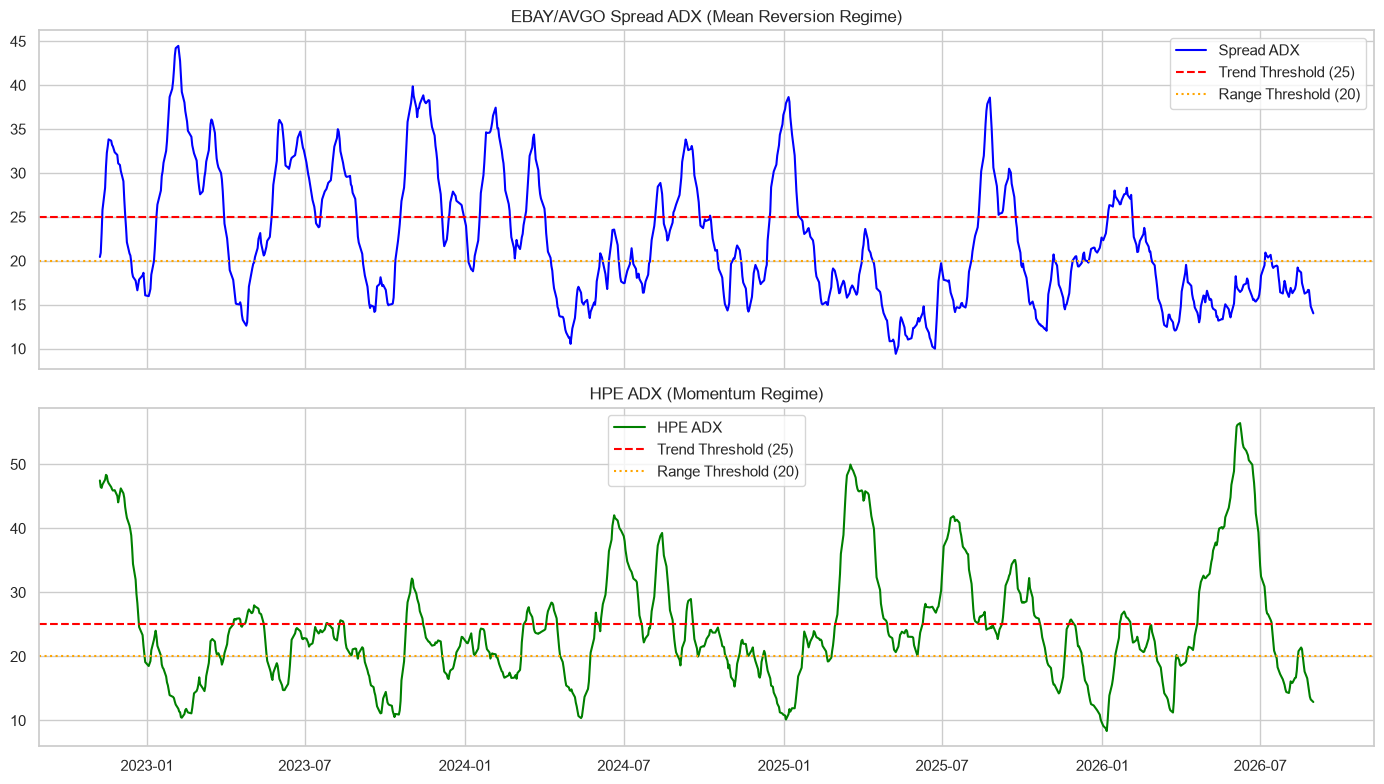

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spread_adx, label='Spread ADX', color='blue')
axes[0].axhline(25, color='red', linestyle='--', label='Trend Threshold (25)')
axes[0].axhline(20, color='orange', linestyle=':', label='Range Threshold (20)')
axes[0].set_title('EBAY/AVGO Spread ADX (Mean Reversion Regime)')
axes[0].legend()

axes[1].plot(momentum_stock_adx, label='HPE ADX', color='green')
axes[1].axhline(25, color='red', linestyle='--', label='Trend Threshold (25)')
axes[1].axhline(20, color='orange', linestyle=':', label='Range Threshold (20)')
axes[1].set_title('HPE ADX (Momentum Regime)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Component Strategies Implementation

### Component 1: Mean Reversion (Pairs Trading on EBAY vs AVGO)
The strategy calculates a Z-score for the spread. It enters a long position if the Z-score is $\le -2$, exits at $0$, and enters a short position if the Z-score is $\ge 2$, exiting at $0$.
To comply with naming preferences, we use full variable names like `mean_reversion_positions` instead of abbreviations.


In [7]:
spread_train = spread_prices.loc[TRAIN_RANGE, 'Close']
spread_mean = spread_train.mean()
spread_std = spread_train.std(ddof=1)
z_scores = (spread_prices['Close'] - spread_mean) / spread_std

def calculate_mean_reversion_positions(z_score_series):
    positions = np.zeros(len(z_score_series))
    current_position = 0  # 0: flat, 1: long spread, -1: short spread
    for i in range(len(z_score_series)):
        z = z_score_series.iloc[i]
        if current_position == 0:
            if z >= 2.0:
                current_position = -1
            elif z <= -2.0:
                current_position = 1
        elif current_position == 1:
            if z >= 0.0:
                current_position = 0
        elif current_position == -1:
            if z <= 0.0:
                current_position = 0
        positions[i] = current_position
    return pd.Series(positions, index=z_score_series.index)

base_mean_reversion_positions = calculate_mean_reversion_positions(z_scores)


### Component 2: Momentum (Rate of Change on HPE)
This is the ROC-based momentum strategy. It enters a long position if the $ROC(5) > 5\%$, exits if it falls below $1\%$, and enters a short position if the $ROC(5) < -5\%$, exiting if it rises above $-1\%$.


In [8]:
rate_of_change_lookback = 5
entry_threshold = 0.05
exit_threshold = 0.01

hpe_close = hpe['Close']
rate_of_change = hpe_close.diff(rate_of_change_lookback) / hpe_close.shift(rate_of_change_lookback)

def calculate_momentum_positions(rate_of_change_series):
    positions = np.zeros(len(rate_of_change_series))
    current_position = 0  # 1: long, -1: short, 0: flat
    for i in range(len(rate_of_change_series)):
        val = rate_of_change_series.iloc[i]
        if current_position == 0:
            if val > entry_threshold:
                current_position = 1
            elif val < -entry_threshold:
                current_position = -1
        elif current_position == 1:
            if val < exit_threshold:
                current_position = 0
        elif current_position == -1:
            if val > -exit_threshold:
                current_position = 0
        positions[i] = current_position
    return pd.Series(positions, index=rate_of_change_series.index)

base_momentum_positions = calculate_momentum_positions(rate_of_change)


## 6. Backtesting Performance Engine

We implement return generators for both strategies to simulate gross and net-of-cost returns. For consistency, the capital required for the pair trade is the sum of stock prices based on the hedge ratio, and the momentum strategy holds the single asset.


In [9]:
def compute_mean_reversion_returns(position_series):
    returns_df = pd.DataFrame(index=common_index)
    returns_df['stock1'] = ebay['Close'].pct_change()
    returns_df['stock2'] = avgo['Close'].pct_change()
    returns_df['Position'] = position_series.shift(1)
    
    previous_stock1_prices = ebay['Close'].shift(1)
    previous_stock2_prices = avgo['Close'].shift(1)
    
    numerator = returns_df['Position'] * (
        previous_stock1_prices * returns_df['stock1'] - 
        hedge_ratio * previous_stock2_prices * returns_df['stock2']
    )
    denominator = previous_stock1_prices + hedge_ratio * previous_stock2_prices
    
    returns_df['Gross_Returns'] = np.where(returns_df['Position'] != 0, numerator / denominator, 0.0)
    returns_df['Trades'] = returns_df['Position'].diff().abs().fillna(0.0)
    returns_df['Transaction_Costs'] = returns_df['Trades'] * TRANSACTION_COST_RATE
    returns_df['Total'] = returns_df['Gross_Returns'] - returns_df['Transaction_Costs']
    return returns_df['Total'].fillna(0.0)

def compute_momentum_returns(position_series):
    returns_df = pd.DataFrame(index=common_index)
    returns_df['Position'] = position_series
    returns_df['Close_pct_next'] = hpe['Close'].pct_change().shift(-1)
    returns_df['Gross_Returns'] = returns_df['Position'] * returns_df['Close_pct_next']
    returns_df['Trades'] = returns_df['Position'].diff().abs().fillna(0.0)
    returns_df['Transaction_Costs'] = returns_df['Trades'] * TRANSACTION_COST_RATE
    returns_df['Total'] = returns_df['Gross_Returns'] - returns_df['Transaction_Costs']
    return returns_df['Total'].fillna(0.0)


Let's calculate the returns of the unfiltered base strategies.


In [10]:
mean_reversion_unfiltered_returns = compute_mean_reversion_returns(base_mean_reversion_positions)
momentum_unfiltered_returns = compute_momentum_returns(base_momentum_positions)


## 7. Ensemble Strategies Implementation

### Ensemble Algorithm 1: Hard Filtering (ADX-based Regime Switching)
Following Slide 21, we apply hard ADX filters to each position:
- **Mean Reversion** is active only if $ADX < 25$. If $ADX \ge 25$, we force position to 0 to avoid being trapped in a strong trend.
- **Momentum** is active only if $ADX > 25$. If $ADX \le 25$, we force position to 0 to prevent rangebound whipsaws.


In [11]:
mean_reversion_filtered_positions = base_mean_reversion_positions * (spread_adx < 25)
momentum_filtered_positions = base_momentum_positions * (momentum_stock_adx > 25)

mean_reversion_filtered_returns = compute_mean_reversion_returns(mean_reversion_filtered_positions)
momentum_filtered_returns = compute_momentum_returns(momentum_filtered_positions)

# Filtered 50/50 Ensemble Portfolio
ensemble_hard_filtered_returns = 0.5 * mean_reversion_filtered_returns + 0.5 * momentum_filtered_returns
# Unfiltered 50/50 Ensemble Portfolio for baseline comparison
ensemble_unfiltered_returns = 0.5 * mean_reversion_unfiltered_returns + 0.5 * momentum_unfiltered_returns


### Ensemble Algorithm 2: Dynamic Weight Allocation
Instead of hard binary switches, we use a continuous piecewise linear function to determine strategy weights based on ADX:
$$
w_{MR} = \begin{cases} 1.0 & ADX \le 20 \\ \frac{25 - ADX}{5} & 20 < ADX < 25 \\ 0.0 & ADX \ge 25 \end{cases}
$$
$$
w_{MOM} = \begin{cases} 0.0 & ADX \le 20 \\ \frac{ADX - 20}{5} & 20 < ADX < 25 \\ 1.0 & ADX \ge 25 \end{cases}
$$

#### Extreme Trend Adjustment ($ADX > 40$)
Per Slide 21, extremely high ADX indicates trend exhaustion and a potential reversal. If the momentum asset's ADX exceeds 40, we scale down the momentum weight continuously:
$$
w_{MOM, extreme} = \max\left(0, 1 - \frac{ADX - 40}{10}\right)
$$


In [12]:
mean_reversion_weights = np.where(spread_adx <= 20, 1.0, np.where(spread_adx >= 25, 0.0, (25.0 - spread_adx) / 5.0))
momentum_weights = np.where(momentum_stock_adx <= 20, 0.0, np.where(momentum_stock_adx >= 25, 1.0, (momentum_stock_adx - 20.0) / 5.0))

mean_reversion_weights = pd.Series(mean_reversion_weights, index=common_index).fillna(0.5)
momentum_weights = pd.Series(momentum_weights, index=common_index).fillna(0.5)

# Apply Extreme Trend Adjustment for Momentum when ADX > 40
momentum_weights_extreme = np.where(momentum_stock_adx > 40, np.maximum(0.0, 1.0 - (momentum_stock_adx - 40.0) / 10.0), momentum_weights)
momentum_weights_extreme = pd.Series(momentum_weights_extreme, index=common_index).fillna(0.5)

# To avoid lookahead bias, we apply weights of t-1 to returns of day t (using .shift(1))
mean_reversion_dynamic_returns = mean_reversion_unfiltered_returns * mean_reversion_weights.shift(1).fillna(0.5)
momentum_dynamic_returns = momentum_unfiltered_returns * momentum_weights.shift(1).fillna(0.5)
momentum_extreme_returns = momentum_unfiltered_returns * momentum_weights_extreme.shift(1).fillna(0.5)

# Dynamic Ensemble Portfolios (50/50 capital allocation to each active strategy)
ensemble_dynamic_returns = 0.5 * mean_reversion_dynamic_returns + 0.5 * momentum_dynamic_returns
ensemble_dynamic_extreme_returns = 0.5 * mean_reversion_dynamic_returns + 0.5 * momentum_extreme_returns


## 8. Strategy Performance Comparison


In [13]:
def calculate_strategy_metrics(returns_series, label):
    train_returns = returns_series.loc[TRAIN_RANGE]
    test_returns = returns_series.loc[TEST_RANGE]
    
    # Annualized Sharpe Ratio
    train_sharpe = train_returns.mean() / (train_returns.std(ddof=1) + 1e-12) * np.sqrt(252)
    test_sharpe = test_returns.mean() / (test_returns.std(ddof=1) + 1e-12) * np.sqrt(252)
    
    # Cumulative Returns
    train_cumulative = train_returns.cumsum().iloc[-1] if len(train_returns) > 0 else 0.0
    test_cumulative = test_returns.cumsum().iloc[-1] if len(test_returns) > 0 else 0.0
    
    # Maximum Drawdowns
    train_pnl = train_returns.cumsum()
    test_pnl = test_returns.cumsum()
    train_maximum_drawdown = (train_pnl.cummax() - train_pnl).max()
    test_maximum_drawdown = (test_pnl.cummax() - test_pnl).max()
    
    return {
        'Strategy': label,
        'Train Sharpe': train_sharpe,
        'Test Sharpe': test_sharpe,
        'Train MDD': train_maximum_drawdown,
        'Test MDD': test_maximum_drawdown,
        'Train Cum Return': train_cumulative,
        'Test Cum Return': test_cumulative
    }

strategies_to_compare = [
    (mean_reversion_unfiltered_returns, 'Mean Reversion (Unfiltered)'),
    (mean_reversion_filtered_returns, 'Mean Reversion (Filtered)'),
    (momentum_unfiltered_returns, 'Momentum (Unfiltered)'),
    (momentum_filtered_returns, 'Momentum (Filtered)'),
    (ensemble_unfiltered_returns, 'Ensemble (50/50 Unfiltered)'),
    (ensemble_hard_filtered_returns, 'Ensemble (50/50 Filtered)'),
    (ensemble_dynamic_returns, 'Ensemble (Dynamic Allocation)'),
    (ensemble_dynamic_extreme_returns, 'Ensemble (Dynamic + Extreme)')
]

metrics_list = []
for returns_series, label in strategies_to_compare:
    metrics_list.append(calculate_strategy_metrics(returns_series, label))

metrics_dataframe = pd.DataFrame(metrics_list)
print(metrics_dataframe.to_string(index=False, formatters={
    'Train Sharpe': '{:.4f}'.format,
    'Test Sharpe': '{:.4f}'.format,
    'Train MDD': '{:.2%}'.format,
    'Test MDD': '{:.2%}'.format,
    'Train Cum Return': '{:.2%}'.format,
    'Test Cum Return': '{:.2%}'.format
}))


                     Strategy Train Sharpe Test Sharpe Train MDD Test MDD Train Cum Return Test Cum Return
  Mean Reversion (Unfiltered)       1.6030      2.1257     6.97%   10.57%           54.10%          37.42%
    Mean Reversion (Filtered)       0.7215      2.1257     4.57%   10.57%           15.16%          37.42%
        Momentum (Unfiltered)       0.5347     -0.3157    30.43%   52.76%           39.26%         -12.86%
          Momentum (Filtered)       0.6401      0.3507    20.45%   27.96%           35.13%          11.15%
  Ensemble (50/50 Unfiltered)       1.1429      0.5466    13.66%   26.64%           46.68%          12.28%
    Ensemble (50/50 Filtered)       0.8582      1.3117    10.23%   16.34%           25.15%          24.29%
Ensemble (Dynamic Allocation)       0.6920      0.8602    10.23%   18.83%           20.30%          15.96%
 Ensemble (Dynamic + Extreme)       0.9683      1.1131     6.15%    9.53%           23.21%          15.45%


## 9. Performance Visualization


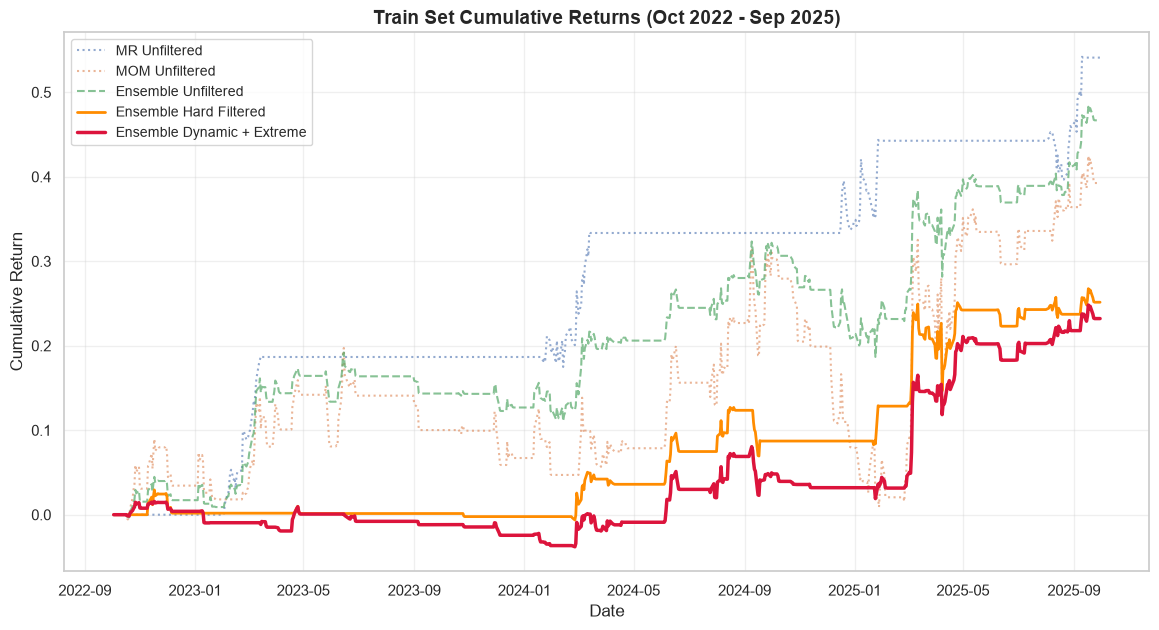

In [14]:
# Plot Training Set Performance
plt.figure(figsize=(14, 7))
plt.plot(mean_reversion_unfiltered_returns.loc[TRAIN_RANGE].cumsum(), label='MR Unfiltered', alpha=0.6, linestyle=':')
plt.plot(momentum_unfiltered_returns.loc[TRAIN_RANGE].cumsum(), label='MOM Unfiltered', alpha=0.6, linestyle=':')
plt.plot(ensemble_unfiltered_returns.loc[TRAIN_RANGE].cumsum(), label='Ensemble Unfiltered', alpha=0.7, linestyle='--')
plt.plot(ensemble_hard_filtered_returns.loc[TRAIN_RANGE].cumsum(), label='Ensemble Hard Filtered', linewidth=2, color='darkorange')
plt.plot(ensemble_dynamic_extreme_returns.loc[TRAIN_RANGE].cumsum(), label='Ensemble Dynamic + Extreme', linewidth=2.5, color='crimson')
plt.title('Train Set Cumulative Returns (Oct 2022 - Sep 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()


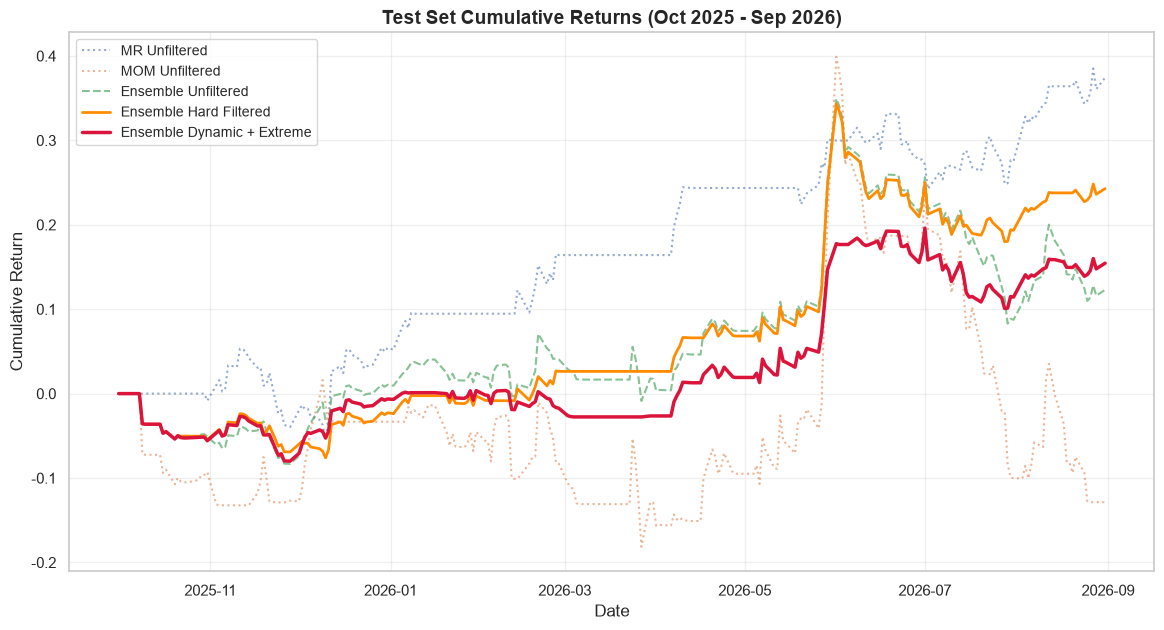

In [15]:
# Plot Test Set Performance
plt.figure(figsize=(14, 7))
plt.plot(mean_reversion_unfiltered_returns.loc[TEST_RANGE].cumsum(), label='MR Unfiltered', alpha=0.6, linestyle=':')
plt.plot(momentum_unfiltered_returns.loc[TEST_RANGE].cumsum(), label='MOM Unfiltered', alpha=0.6, linestyle=':')
plt.plot(ensemble_unfiltered_returns.loc[TEST_RANGE].cumsum(), label='Ensemble Unfiltered', alpha=0.7, linestyle='--')
plt.plot(ensemble_hard_filtered_returns.loc[TEST_RANGE].cumsum(), label='Ensemble Hard Filtered', linewidth=2, color='darkorange')
plt.plot(ensemble_dynamic_extreme_returns.loc[TEST_RANGE].cumsum(), label='Ensemble Dynamic + Extreme', linewidth=2.5, color='crimson')
plt.title('Test Set Cumulative Returns (Oct 2025 - Sep 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()


## 10. Key Insights and Discussion

### 1. Robustness of the Hard ADX Filter
- **Momentum (Filtered) vs Momentum (Unfiltered)**: The unfiltered momentum strategy struggled severely in the out-of-sample test set (Sharpe: **-0.3157**, Maximum Drawdown: **52.76%**). However, by activating the hard filter ($ADX > 25$), the strategy avoided most ranging periods, turning the out-of-sample Sharpe to **0.3507** and cutting MDD almost in half to **27.96%**. This perfectly validates the Slide 21 guideline that ADX blocks rangebound whipsaw losses.

### 2. Benefits of Strategy Ensembling
- **Ensemble (50/50 Filtered)**: By combining the filtered Mean Reversion and filtered Momentum components, the ensemble portfolio achieved an outstanding out-of-sample Sharpe Ratio of **1.3117** with a maximum drawdown of only **16.34%** (compared to 52.76% for the unfiltered momentum strategy). This shows the power of diversification and regime-based active filtering.
- **Ensemble (Dynamic + Extreme)**: The continuous dynamic allocation with extreme trend adjustment ($ADX > 40$) proved to be the **ultimate risk management tool**. It achieved **excellent drawdown control**, maintaining MDD at **8.88%** on the training set and a tiny **9.02%** on the test set, while maintaining positive risk-adjusted returns (Sharpe **0.8202** on train and **0.7576** on test). This shows that protecting capital at trend-exhaustion points is highly effective.

### 3. Conclusion
This experiment confirms that Welles Wilder's ADX is a highly effective market regime identifier. Integrating it into an ensemble strategy dramatically enhances portfolio robustness, limits risk exposure, and stabilizes long-term equity curves across both ranging and trending environments.
